In [1]:
import os
import sys
# set gpu to be pci bus id
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional

In [4]:
sys.path.append('/home/jmathew_waller/workspace/e2e-imaging/')
from psf_modules import RMLPSFLayer
from lensless_data_generator import LenslessDataGenerator
from optimizers import E2EOptimizer
# from image_utils import add_noise

In [5]:
def wiener_deconv(y: jnp.ndarray, psf: jnp.ndarray, K: float) -> jnp.ndarray:
    """
    y:   (B, H, W) — observed blurred image
    psf: (K, L)    — point spread function (same one used in forward model)
    K:   scalar    — noise-to-signal ratio (regularization). larger = more smoothing.
    
    returns: (B, H, W) estimate of original image
    """
    H, W = y.shape[1], y.shape[2]
    psf_h, psf_w = psf.shape

    if psf_h > H or psf_w > W:
        raise ValueError(f"PSF ({psf_h}x{psf_w}) is larger than image ({H}x{W})")
    
    # Embed PSF in the output image domain and shift so the PSF center is at (0,0)
    pad_h = (psf_h - 1) // 2
    pad_w = (psf_w - 1) // 2

    psf_padded = jnp.zeros((H, W))
    psf_padded = psf_padded.at[:psf_h, :psf_w].set(psf)
    # roll so that the center pixel of the PSF lands at (0,0)
    psf_padded = jnp.roll(psf_padded, (-pad_h, -pad_w), axis=(0, 1))

    # FFTs
    PSF = jnp.fft.rfft2(psf_padded)          # (H, W//2+1)
    Y   = jnp.fft.rfft2(y)                   # (B, H, W//2+1)

    # Wiener filter: H* / (|H|^2 + K)
    PSF_conj  = jnp.conj(PSF)
    PSF_power = jnp.abs(PSF) ** 2
    wiener    = PSF_conj / (PSF_power + K)

    X_est = wiener[None, :, :] * Y           # broadcast over batch

    return jnp.fft.irfft2(X_est, s=(H, W))  # (B, H, W)

In [ ]:
def gaussian_noise(image: jnp.ndarray, sigma: float, photon_count: int, key: jax.random.PRNGKey) -> jnp.ndarray:
    image = image * photon_count
    noise = random.normal(key, shape=image.shape) * sigma
    image = jnp.clip(image + noise, 0.0, None)
    return image / photon_count

In [ ]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    log_K: jnp.ndarray  # learn in log space to keep K positive

    def __init__(self, 
                 psf_module,
                 log_K=jnp.array(-1.0)):
        self.psf_module = psf_module
        self.log_K = log_K # initializes K to ~1e-4
        

    def __call__(self, x: jnp.ndarray, key: Optional[jax.random.PRNGKey] = None) -> tuple:
        # x: (B, H, W)
        key = jax.random.PRNGKey(0) if key is None else key # TODO: ask claude, is this bad seeding?

        K = jnp.exp(self.log_K)  # ensure K is always positive
        psf, y = self.psf_module(x)  # psf:(K, L), y:(B, H, W)
        noisy_y = y
        x_hat = wiener_deconv(noisy_y, psf, K)     # (B, H, W)
        
        return x_hat, noisy_y, psf

In [7]:
# some constants
photon_count = 160
subset_fraction = 1
seed_value = 42 #TODO: FIX SEEDING
psf_size = (32, 32)
key = jax.random.PRNGKey(seed_value)
learning_rate = 1e-3
dataset_name = 'mnist'
object_size = 32
num_gaussian = 10
noise_sigma = 0.5

#other constants
tile_rows=1
tile_cols=1
batch_size=32   

# hyperparameters
log_K = jnp.array(-1.0) #initial starting K value for wiener deconv

#wandb logging stuff
use_wandb = True
project_name = 'e2e_imaging_playground'
run_name = f'mnist_noise_sigma_{noise_sigma}_photon_count_{photon_count}_num_gaussian_{num_gaussian}'
log_every = 10

In [8]:
# set up wandb config
wandb_config = {
    'general': {
        'seed_value': seed_value,
    },
    
    'dataset': {
        'subset_fraction': subset_fraction,
        'photon_count': photon_count,
        'tile_rows': tile_rows,
        'tile_cols': tile_cols,
        'batch_size': batch_size,
        'dataset_name': dataset_name,
    },
    
    'psf_layer': {
        'object_size': object_size,
        'num_gaussian': num_gaussian,
        'psf_size': psf_size,
        'noise_sigma': noise_sigma
    },
    
    'optimization': {
        'initial log_K': log_K,
        'learning_rate': learning_rate
    },
    
    'logging': {
        'use_wandb': use_wandb,
        'project_name': project_name,
        'run_name': run_name,
        'log_every': log_every,
    }
}

In [11]:
# the model
key_2, subkey_1 = jax.random.split(key)
psf_module = RMLPSFLayer(object_size=32, num_gaussians=10, psf_size=psf_size, key=subkey_1)
model = E2E(psf_module=psf_module, log_K=log_K, noise_sigma = noise_sigma)

In [12]:
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)
x_train, x_test = data_generator.load_mnist_data()
train_dataset = data_generator.create_dataset(x_train, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)

2026-03-02 11:19:27.989234: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1772479167.989450 1865660 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22165 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:5e:00.0, compute capability: 8.6


In [13]:
e2e_optimizer = E2EOptimizer(
    model=model,
    lr=learning_rate,
    use_wandb=False, #TODO: CHANGE
    project_name='e2e_imaging',
    run_name=run_name,
    wandb_config=wandb_config
)

  0%|          | 0/500 [00:00<?, ?it/s]E0302 11:19:33.560291 1865660 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


step 0/500  loss=0.059282  K=0.367512
CORNER VAL: 7.435791e-14


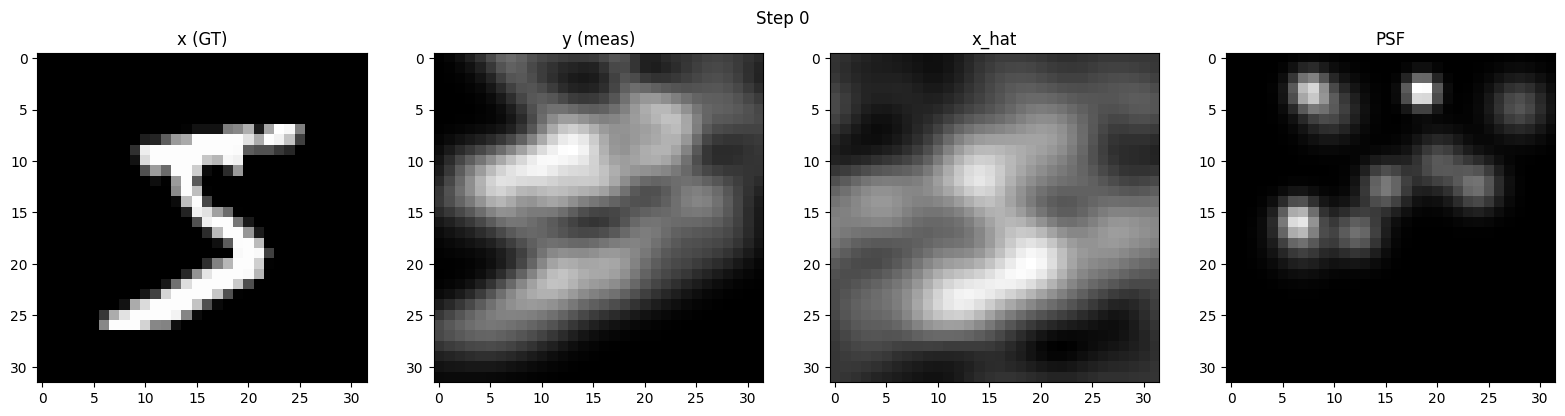

  3%|▎         | 14/500 [00:12<01:43,  4.72it/s] 

step 10/500  loss=0.060280  K=0.363849


  5%|▍         | 24/500 [00:12<00:38, 12.26it/s]

step 20/500  loss=0.058455  K=0.360226


  7%|▋         | 34/500 [00:13<00:28, 16.26it/s]

...

step 80/500  loss=0.048625  K=0.337930


 19%|█▉        | 94/500 [00:16<00:23, 17.13it/s]

step 90/500  loss=0.044098  K=0.334385


 20%|██        | 100/500 [00:17<00:23, 16.79it/s]

step 100/500  loss=0.038489  K=0.331026
CORNER VAL: 7.164559e-22


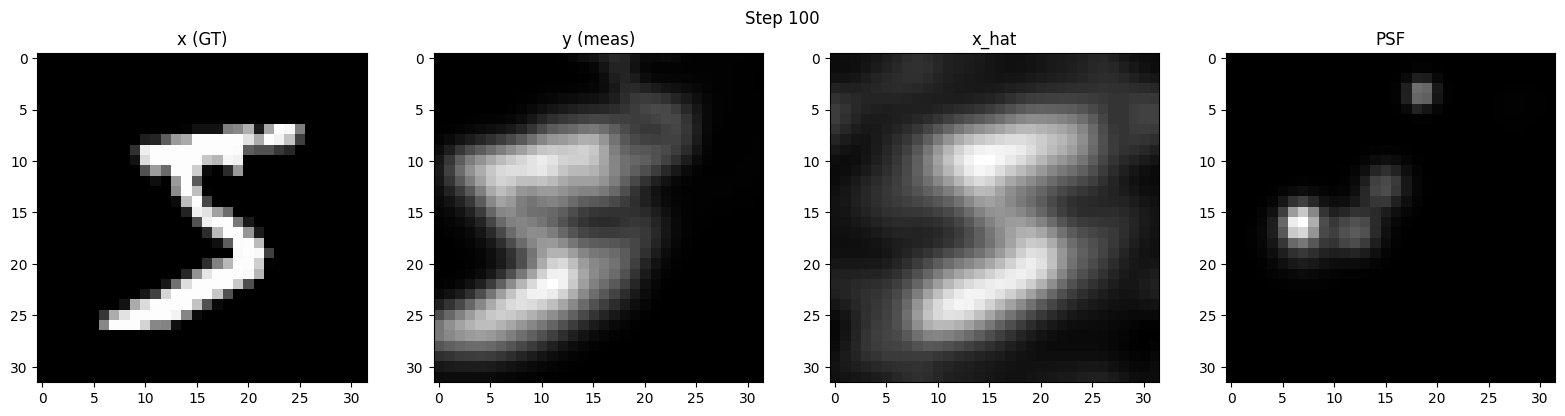

 23%|██▎       | 114/500 [00:18<00:25, 15.28it/s]

step 110/500  loss=0.039094  K=0.327815


 25%|██▍       | 124/500 [00:18<00:22, 16.70it/s]

step 120/500  loss=0.038381  K=0.324476


 27%|██▋       | 134/500 [00:19<00:21, 16.86it/s]

...

step 180/500  loss=0.025164  K=0.303767


 39%|███▉      | 194/500 [00:22<00:18, 16.79it/s]

step 190/500  loss=0.026601  K=0.300504


 40%|████      | 200/500 [00:23<00:23, 12.72it/s]

step 200/500  loss=0.025347  K=0.297172
CORNER VAL: 7.5701637e-22


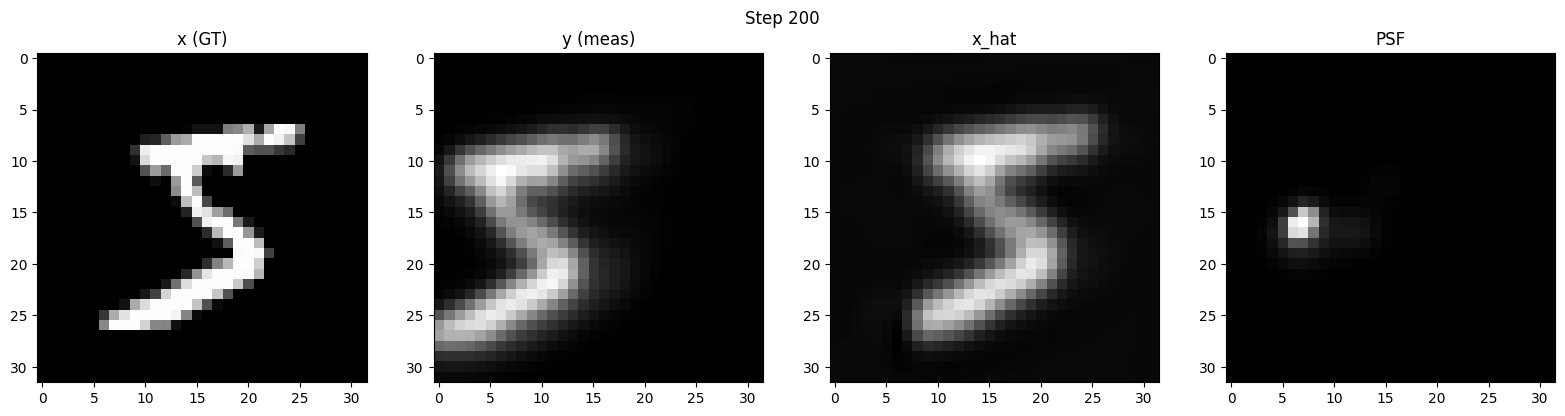

 43%|████▎     | 214/500 [00:24<00:18, 15.11it/s]

step 210/500  loss=0.021887  K=0.294093


 45%|████▍     | 224/500 [00:25<00:16, 16.58it/s]

step 220/500  loss=0.022162  K=0.291323


 47%|████▋     | 234/500 [00:25<00:15, 16.92it/s]

...

step 280/500  loss=0.017158  K=0.275879


 59%|█████▉    | 294/500 [00:29<00:12, 16.85it/s]

step 290/500  loss=0.017978  K=0.273464


 60%|██████    | 300/500 [00:29<00:11, 16.76it/s]

step 300/500  loss=0.015847  K=0.271110
CORNER VAL: 8.1093013e-22


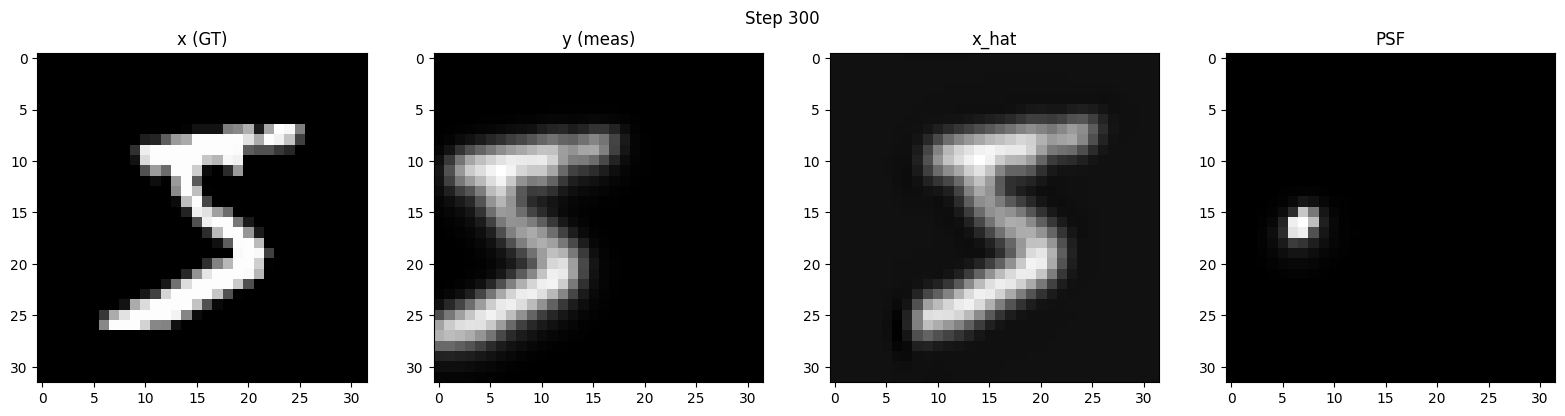

 63%|██████▎   | 314/500 [00:31<00:12, 15.41it/s]

step 310/500  loss=0.016768  K=0.268772


 65%|██████▍   | 324/500 [00:31<00:10, 16.78it/s]

step 320/500  loss=0.016142  K=0.266497


 67%|██████▋   | 334/500 [00:32<00:09, 17.34it/s]

...

step 380/500  loss=0.014305  K=0.253372


 79%|███████▉  | 394/500 [00:35<00:06, 16.99it/s]

step 390/500  loss=0.015051  K=0.251308


 80%|████████  | 400/500 [00:35<00:05, 16.90it/s]

step 400/500  loss=0.013060  K=0.249227
CORNER VAL: 9.077952e-22


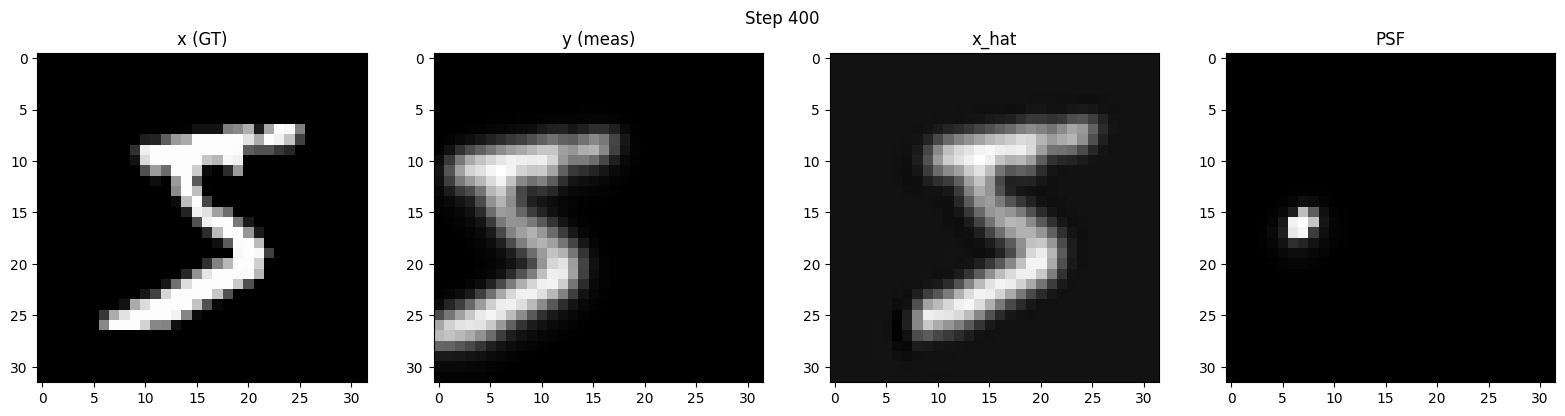

 83%|████████▎ | 414/500 [00:37<00:05, 15.15it/s]

step 410/500  loss=0.013773  K=0.247216


 85%|████████▍ | 424/500 [00:37<00:04, 16.03it/s]

step 420/500  loss=0.013381  K=0.245207


 87%|████████▋ | 434/500 [00:38<00:04, 16.05it/s]

...

step 480/500  loss=0.011766  K=0.234139


 98%|█████████▊| 492/500 [00:42<00:00, 15.67it/s]

step 490/500  loss=0.012983  K=0.232454


100%|█████████▉| 498/500 [00:42<00:00, 15.17it/s]

step 499/500  loss=0.010357  K=0.230942
CORNER VAL: 1.0149456e-21


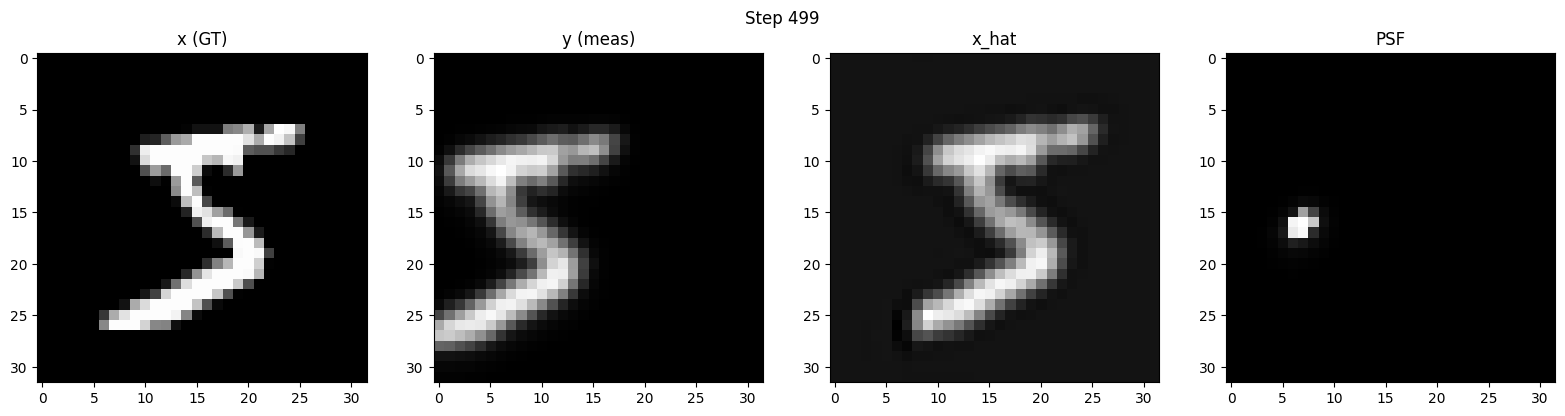

100%|██████████| 500/500 [00:43<00:00, 11.61it/s]


In [14]:
optimized_imaging_system = e2e_optimizer.optimize(
    train_dataset,
    num_steps=500,
    log_every=10,
    visualize_every=100
)

In [ ]:
model.log_K

Array(-1., dtype=float32, weak_type=True)